# Notebook purpose

This notebook preserves the exploratory workflow from `cluster_deputados.ipynb`.

Purpose: Explore deputy-level UMAP and HDBSCAN clustering visualizations.

Related production code/script: `src/clustering/deputies.py`, `src/clustering/optimization.py`, `scripts/run_clustering.py`.


In [1]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import os

# Bibliotecas para a mágica acontecer
import umap.umap_ as umap
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
party_colors = {
    # Paleta de alto contraste para máxima diferenciação visual.
    "PT": "#E6194B",    # Vermelho
    "MDB": "#046600",    # Azul
    "PSDB": "#3cb44b",  # Verde
    "PL": "#ffe119",    # Amarelo
    "DEM": "#4363d8",    # Magenta
    "UNIÃO": "#4363d8",  # Laranja
    "PP": "#ff7b00",    # Roxo
    "PSB": "#e01f3f",    # Laranja
    "PCdoB": "#3A0000",  # Marrom (Vinho)
    "PDT": "#c42895",    # Ciano
    "PSOL": "#490364",   # Marrom (Sépia)
}

In [3]:
# --- Passo 1: Carregar e Preparar os Dados ---
print("Carregando dados pré-processados...")
try:
    df = pd.read_csv('data/discursos_camara_2003_2025_limpos.csv')
    embeddings = np.load('data/discursos_camara_2003_2025_limpos_Linq_embeddings_norm.npy')
    assert len(df) == len(embeddings), "O número de linhas no CSV e nos embeddings não bate!"
    print(f"Total de discursos carregados: {len(df)}")
except FileNotFoundError:
    print("Erro: Arquivos 'discursos_limpos.csv' ou 'embeddings_discursos.npy' não encontrados.")
    exit()

embedding_list = [emb for emb in embeddings]
df['embedding'] = embedding_list

df = df[df['partido'].isin(party_colors.keys())]
print(f"Total de discursos dos partidos selecionados: {len(df)}")

Carregando dados pré-processados...
Total de discursos carregados: 453211
Total de discursos dos partidos selecionados: 354719


In [4]:
deputy_embeddings_df = df.groupby('nome')['embedding'].apply(lambda x: np.mean(x.tolist(), axis=0))
deputy_embeddings_df = pd.DataFrame(deputy_embeddings_df.tolist(), index=deputy_embeddings_df.index)

high_dim_embeddings = deputy_embeddings_df.values
print(f"Embeddings agregados para {len(deputy_embeddings_df)} deputados. Dimensão original: {high_dim_embeddings.shape[1]}")

Embeddings agregados para 1658 deputados. Dimensão original: 4096


Reduzindo dimensionalidade para D com UMAP...


/home/flaviossf/defaultenv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/flaviossf/defaultenv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/flaviossf/defaultenv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/flaviossf/defaultenv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/flaviossf/defaultenv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed

Foram encontrados 49 clusters principais.
Reduzindo dimensionalidade para 2D para visualização...
Preparando dados para o gráfico...
Gerando o gráfico com os clusters (cluster -1 em preto)...

✔️ Gráfico com clusters salvo como 'mapa_politico_clusters_hdbscan.png'


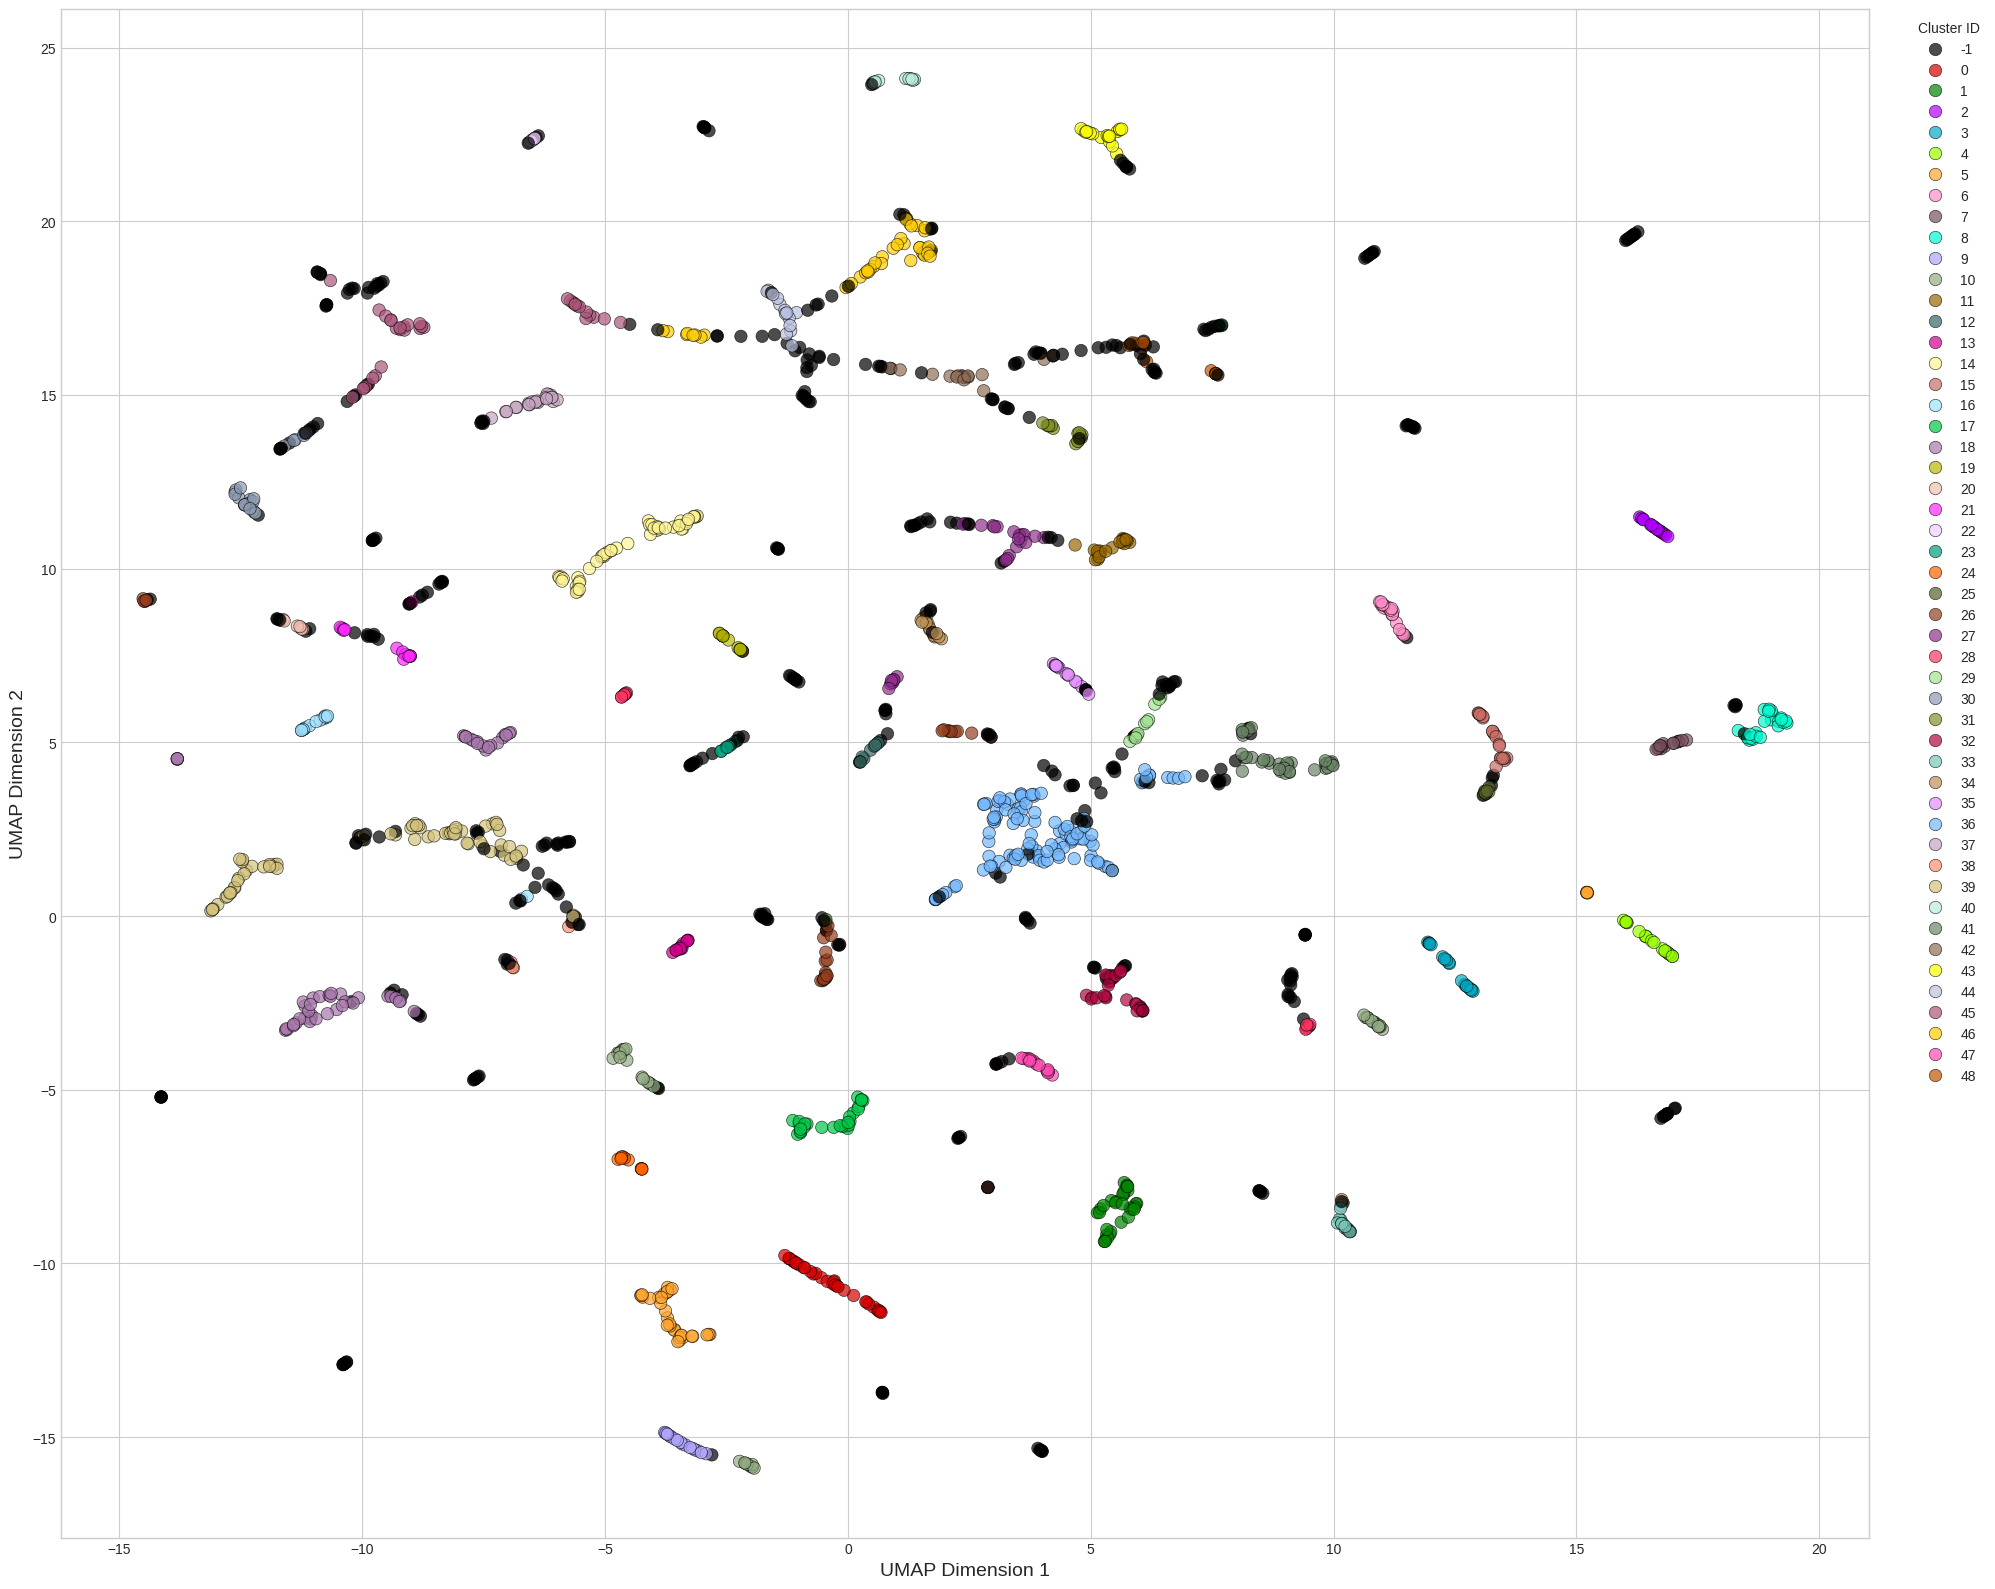


--- Analisando e Salvando a Composição dos Clusters ---


In [5]:



# --- Passo 3: REDUÇÃO PARA ANÁLISE 
print(f"Reduzindo dimensionalidade para D com UMAP...")
reducer_analysis = umap.UMAP(
    n_components=10,
    n_neighbors=5,
    min_dist=0.0,
    metric='euclidean', 
    random_state=42
)
embeddings_reduzidos = reducer_analysis.fit_transform(high_dim_embeddings)

# --- Passo 4: CLUSTERIZAÇÃO COM HDBSCAN NOS DADOS REDUZIDOS ---
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=6,
    cluster_selection_epsilon=0.15000000000000002,
    cluster_selection_method='eom',
    min_samples=10,  # Para evitar que pontos isolados sejam considerados ruído
    metric='euclidean', # UMAP otimiza para distância Euclidiana no seu espaço de saída
    
)
cluster_labels = clusterer.fit_predict(embeddings_reduzidos)

#salvar cluster e quanto representa do todo em percentual
df_clusters = pd.DataFrame({
    'cluster': cluster_labels
})
df_clusters['count'] = 1
df_clusters = df_clusters.groupby('cluster').count().reset_index()
df_clusters['percentual'] = (df_clusters['count'] / df_clusters['count'].sum()) * 100
df_clusters.to_csv('data/aaaclusterizacao_hdbscan.csv', index=False)

num_clusters = len(np.unique(cluster_labels)) - (1 if -1 in cluster_labels else 0)
print(f"Foram encontrados {num_clusters} clusters principais.")

# --- Passo 5: REDUÇÃO PARA VISUALIZAÇÃO (ex: 50 -> 2) ---
print("Reduzindo dimensionalidade para 2D para visualização...")
reducer_viz = umap.UMAP(
    n_components=2,
    n_neighbors=5,
    min_dist=0.3,
    random_state=42
)
embedding_2d = reducer_viz.fit_transform(embeddings_reduzidos) # Reduzimos os dados já reduzidos

# --- Passo 6: Preparar DataFrame para Plotagem ---
print("Preparando dados para o gráfico...")
df_plot = pd.DataFrame(embedding_2d, columns=['x', 'y'])
df_plot['nome'] = deputy_embeddings_df.index
df_plot['cluster'] = cluster_labels.astype(str)

party_map = df.drop_duplicates('nome', keep='last').set_index('nome')['partido']
df_plot['partido'] = df_plot['nome'].map(party_map)

# --- Passo 7: Visualização Final ---
print("Gerando o gráfico com os clusters (cluster -1 em preto)...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(20, 16))

# --- LÓGICA DA PALETA PERSONALIZADA ---

# 1. Pega todos os IDs de cluster únicos (ex: ['-1', '0', '1', '2'])
df_plot['cluster'] = df_plot['cluster'].astype(int)  # Garante que os IDs sejam strings
cluster_ids = sorted(df_plot['cluster'].unique())

# 2. Pega o número de clusters "reais" (todos, exceto o -1)
num_real_clusters = len([cid for cid in cluster_ids if cid != -1])

import colorcet as cc


# 3. Gera uma lista de cores apenas para os clusters reais usando a paleta 'husl'
#    Isso garante que as cores sejam distintas e bonitas.
real_cluster_colors = cc.glasbey_light[:num_real_clusters]

# 4. Cria o dicionário de cores final
palette_dict = {}
color_index = 0
for cid in cluster_ids:
    if cid == -1:
        palette_dict[cid] = '#000000'  # Preto para o cluster de ruído
    else:
        palette_dict[cid] = real_cluster_colors[color_index]
        color_index += 1
        
# --- FIM DA LÓGICA DA PALETA ---


# Agora, usamos o `palette_dict` na nossa chamada de plotagem
sns.scatterplot(
    data=df_plot, 
    x='x', 
    y='y', 
    hue='cluster',
    palette=palette_dict, # <-- USA NOSSA PALETA PERSONALIZADA
    s=80, alpha=0.7,
    edgecolor='black', linewidth=0.5,
    ax=ax,
    hue_order=cluster_ids # Garante que a ordem na legenda fique correta
)

ax.set_xlabel('UMAP Dimension 1', fontsize=14)
ax.set_ylabel('UMAP Dimension 2', fontsize=14)
ax.legend(title='Cluster ID', bbox_to_anchor=(1.02, 1), loc='upper left')

output_filename = 'mapa_politico_clusters_hdbscan.png'
plt.tight_layout()
plt.savefig(output_filename, dpi=300)
print(f"\n✔️ Gráfico com clusters salvo como '{output_filename}'")
plt.show()

print("\n--- Analisando e Salvando a Composição dos Clusters ---")



Calculando centróides e preparando a visualização aprimorada...

✔️ Gráfico com centroides e fonte dinâmica salvo como 'clusters_deputados.png'


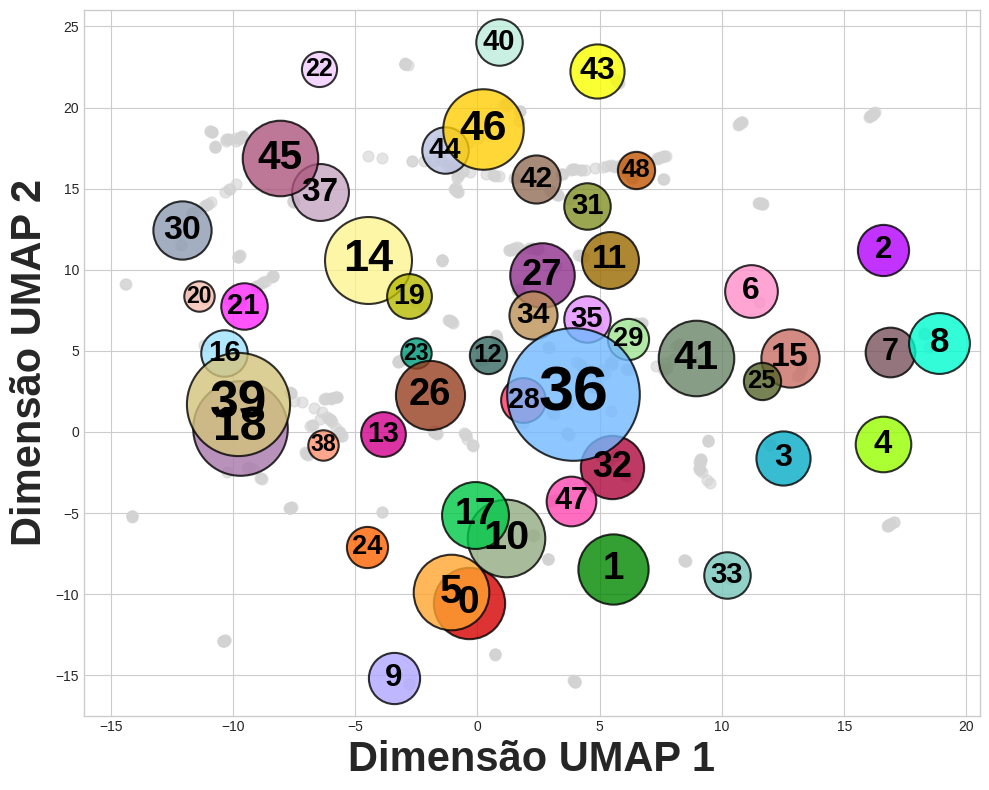

In [ ]:
# --- INÍCIO DO CÓDIGO DA OPÇÃO 1 ---
# Este bloco substitui o seu passo de visualização original.

# 1. Preparar dados dos clusters e centroides
print("Calculando centróides e preparando a visualização aprimorada...")

# Separar pontos de ruído (-1) dos clusters reais
df_noise = df_plot[df_plot['cluster'] == -1]
df_real_clusters = df_plot[df_plot['cluster'] != -1]

# Calcular informações dos centroides (posição média e tamanho) para os clusters reais
cluster_info = df_real_clusters.groupby('cluster').agg(
    x_mean=('x', 'mean'),
    y_mean=('y', 'mean'),
    size=('cluster', 'size')
).reset_index()

# 2. Criar a figura
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 8))

# 3. Plotar os pontos de ruído no fundo
if not df_noise.empty:
    ax.scatter(
        df_noise['x'], df_noise['y'],
        color='lightgray',
        s=60,
        alpha=0.6,
        label='Ruído (Não clusterizado)'
    )

# 4. Plotar os centróides dos clusters reais
size_scale = 80

# --- NOVOS PARÂMETROS PARA A FONTE DINÂMICA ---
# Você pode ajustar estes valores para encontrar o visual perfeito.
font_base_size = 8      # Tamanho mínimo que a fonte terá.
font_scale_factor = 3.5 # Fator de escala. Aumente para a fonte crescer mais rápido.
font_max_size = 50      # Tamanho máximo que a fonte pode atingir.
# ----------------------------------------------------

for index, row in cluster_info.iterrows():
    cluster_id = int(row['cluster'])
    
    # Plotar o ponto do centróide
    ax.scatter(
        row['x_mean'], row['y_mean'],
        s=row['size'] * size_scale,
        color=palette_dict.get(cluster_id, '#333333'),
        edgecolor='black',
        linewidth=1.5,
        alpha=0.8,
        label=f'Cluster {cluster_id}'
    )

    # 5. Adicionar o rótulo com TAMANHO DINÂMICO
    # Calcular o tamanho da fonte com base na raiz quadrada do tamanho do cluster
    dynamic_fontsize = font_base_size + np.sqrt(row['size']) * font_scale_factor
    # Limitar o tamanho da fonte para não ficar absurdamente grande
    dynamic_fontsize = min(dynamic_fontsize, font_max_size)
    
    ax.text(
        row['x_mean'], row['y_mean'],
        s=str(cluster_id),
        # --- MUDANÇA PRINCIPAL AQUI ---
        color='black',         # Dica: 'white' geralmente tem melhor contraste
        fontsize=dynamic_fontsize, # <-- AQUI ESTÁ A MUDANÇA
        # ---------------------------------
        fontweight='bold',
        ha='center',
        va='center'
    )

# 6. Finalizar o gráfico
ax.set_xlabel('UMAP Dimension 1', fontsize=30, fontweight='bold')
ax.set_ylabel('UMAP Dimension 2', fontsize=30, fontweight='bold')
ax.legend().set_visible(False)

# Salvar a figura
output_filename = 'clusters_deputados.png'
plt.tight_layout()
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"\n✔️ Gráfico com centroides e fonte dinâmica salvo como '{output_filename}'")
plt.show()
